In [ ]:
# DA ESEGUIRE SU COLAB PER OTTENERE I PESI DELLE RETI

from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

# Aggiorna questi due path con dove hai messo gli zip su Drive
FBP_ZIP = "/content/drive/MyDrive/fbp.zip"
TV_ZIP = "/content/drive/MyDrive/tv_reconstructions.zip"

LOCAL_FBP_DIR = Path("/content/fbp")
LOCAL_TV_DIR = Path("/content/tv_reconstructions")

if not LOCAL_FBP_DIR.exists():
    print("Estraggo FBP...")
    get_ipython().system('unzip -q "{FBP_ZIP}" -d /content/')
else:
    print("FBP già estratto, salto.")

if not LOCAL_TV_DIR.exists():
    print("Estraggo TV...")
    get_ipython().system('unzip -q "{TV_ZIP}" -d /content/')
else:
    print("TV già estratto, salto.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FBP già estratto, salto.
TV già estratto, salto.


In [2]:
get_ipython().system('pip install -q astra-toolbox')
get_ipython().system('pip install -q git+https://github.com/devangelista2/IPPy.git')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 78.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import time
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from IPPy.nn import models, losses
from IPPy.utilities.metrics import PSNR, SSIM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA L4


In [4]:
class FBPtoTVDataset(Dataset):
    """
    Coppie FBP (input) -> TV (target), per una configurazione angolare
    e uno split specifici. Clip in [0,1] applicato al volo, i file su
    disco restano intatti.
    """

    def __init__(self, fbp_dir: Path, tv_dir: Path, split: str, n_angles: int):
        self.fbp_split_dir = Path(fbp_dir) / split / str(n_angles)
        self.tv_split_dir = Path(tv_dir) / split / str(n_angles)

        assert self.fbp_split_dir.exists(), f"Non trovo {self.fbp_split_dir}"
        assert self.tv_split_dir.exists(), f"Non trovo {self.tv_split_dir}"

        self.rel_paths = sorted(
            p.relative_to(self.fbp_split_dir)
            for p in self.fbp_split_dir.rglob("*.npy")
        )

        missing = [rel for rel in self.rel_paths if not (self.tv_split_dir / rel).exists()]
        assert not missing, f"{len(missing)} file TV mancanti, es: {missing[:3]}"

    def __len__(self):
        return len(self.rel_paths)

    def __getitem__(self, index):
        rel = self.rel_paths[index]
        fbp_arr = np.clip(np.load(self.fbp_split_dir / rel), 0.0, 1.0)
        tv_arr = np.clip(np.load(self.tv_split_dir / rel), 0.0, 1.0)
        x = torch.from_numpy(fbp_arr).float().unsqueeze(0)
        y = torch.from_numpy(tv_arr).float().unsqueeze(0)
        return x, y

In [38]:
# ============================================================
# CONFIGURAZIONE -- modifica qui prima di lanciare
# ============================================================

N_ANGLES = 15   # <-- 90, 45, 30 o 15: quale configurazione stai allenando ora
                # (una UNet separata per ciascuna, rilanci tutto il notebook
                #  cambiando solo questo valore per le altre 3)

CHECKPOINT_DIR = Path(f"/content/drive/MyDrive/unet_checkpoints/{N_ANGLES}")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# --- Architettura UNet ---
MODEL_CONFIG = {
    "ch_in": 1,
    "ch_out": 1,
    "middle_ch": [32, 64, 128, 256],
    "n_layers_per_block": 2,
    "down_layers": ("ResDownBlock", "ResDownBlock", "ResDownBlock"),
    "up_layers": ("ResUpBlock", "ResUpBlock", "ResUpBlock"),
    "final_activation": "sigmoid",   # forza l'output in [0,1], coerente col clip che hai deciso
}

# --- Iperparametri di training ---
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
N_EPOCHS = 25
SAVE_EVERY = 2   # salva un checkpoint su Drive ogni N epoche (resumability)

print(f"Configurazione per N_ANGLES={N_ANGLES}, checkpoint in: {CHECKPOINT_DIR}")

Configurazione per N_ANGLES=15, checkpoint in: /content/drive/MyDrive/unet_checkpoints/15


In [40]:
# shuffle=True solo sul train (l'ordine per la validation non conta,
# non aggiorniamo mai i pesi lì dentro).
# Il sanity check finale conferma che il clip [0,1] funziona correttamente.

train_ds = FBPtoTVDataset(LOCAL_FBP_DIR, LOCAL_TV_DIR, "train", N_ANGLES)
val_ds = FBPtoTVDataset(LOCAL_FBP_DIR, LOCAL_TV_DIR, "validation", N_ANGLES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} immagini, {len(train_loader)} batch")
print(f"Validation: {len(val_ds)} immagini, {len(val_loader)} batch")

# sanity check veloce su una coppia
x, y = train_ds[0]
print(f"Input shape: {x.shape}, range: [{x.min():.3f}, {x.max():.3f}]")
print(f"Target shape: {y.shape}, range: [{y.min():.3f}, {y.max():.3f}]")

Train: 2733 immagini, 171 batch
Validation: 573 immagini, 36 batch
Input shape: torch.Size([1, 256, 256]), range: [0.000, 1.000]
Target shape: torch.Size([1, 256, 256]), range: [0.000, 1.000]


In [14]:
# Non è un training vero: stesso identico batch riusato 20 volte, modello
# e ottimizzatore buttati via alla fine -- serve solo a misurare il tempo
# per passo, non a ottenere un modello utilizzabile. senza amp

model_bench = models.UNet(**MODEL_CONFIG).to(device)
optimizer_bench = torch.optim.Adam(model_bench.parameters(), lr=LEARNING_RATE)
loss_fn_bench = nn.MSELoss()

t0 = time.time()
n_batches_test = 20   # solo un assaggio, non l'epoca intera
for i, (x, y) in enumerate(train_loader):
    if i >= n_batches_test:
        break
    x, y = x.to(device), y.to(device)
    optimizer_bench.zero_grad()
    y_pred = model_bench(x)
    loss = loss_fn_bench(y_pred, y)
    loss.backward()
    optimizer_bench.step()
elapsed = time.time() - t0

sec_per_batch = elapsed / n_batches_test
sec_per_epoch = sec_per_batch * len(train_loader)
print(f"Tempo per batch: {sec_per_batch:.3f}s")
print(f"Stima tempo per epoca (train): {sec_per_epoch:.1f}s (~{sec_per_epoch/60:.1f} min)")
print(f"Stima per {N_EPOCHS} epoche: {sec_per_epoch * N_EPOCHS / 60:.1f} min")

del model_bench, optimizer_bench
torch.cuda.empty_cache() if device.type == "cuda" else None

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0f4ab08f40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0f4ab08f40>if w.is_alive():

Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    assert self._parent_pid == os.getpid(), 'can only test a child process'    
self._shutdown_workers()AssertionError
:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
can only test a child process
    if w.is_alive():Exception ignored 

Tempo per batch: 0.553s
Stima tempo per epoca (train): 94.5s (~1.6 min)
Stima per 25 epoche: 39.4 min


In [15]:
# Non è un training vero: stesso identico batch riusato 20 volte, modello
# e ottimizzatore buttati via alla fine -- serve solo a misurare il tempo
# per passo, non a ottenere un modello utilizzabile. con amp

model_bench_amp = models.UNet(**MODEL_CONFIG).to(device)
optimizer_bench_amp = torch.optim.Adam(model_bench_amp.parameters(), lr=LEARNING_RATE)
loss_fn_bench_amp = nn.MSELoss()
scaler_bench = torch.cuda.amp.GradScaler()

x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

torch.cuda.synchronize()
t0 = time.time()
for _ in range(20):
    optimizer_bench_amp.zero_grad()
    with torch.cuda.amp.autocast():
        y_pred = model_bench_amp(x)
        loss = loss_fn_bench_amp(y_pred, y)
    scaler_bench.scale(loss).backward()
    scaler_bench.step(optimizer_bench_amp)
    scaler_bench.update()
torch.cuda.synchronize()
print(f"Tempo per batch (L4 + mixed precision): {(time.time()-t0)/20:.3f}s")

del model_bench_amp, optimizer_bench_amp, scaler_bench
torch.cuda.empty_cache()

/tmp/ipykernel_6748/1676426008.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_bench = torch.cuda.amp.GradScaler()
/tmp/ipykernel_6748/1676426008.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Tempo per batch (L4 + mixed precision): 0.284s


lr=1e-03  loss iniziale=0.02640  loss finale=0.01071
lr=1e-04  loss iniziale=0.04218  loss finale=0.00353
lr=1e-05  loss iniziale=0.09990  loss finale=0.01049


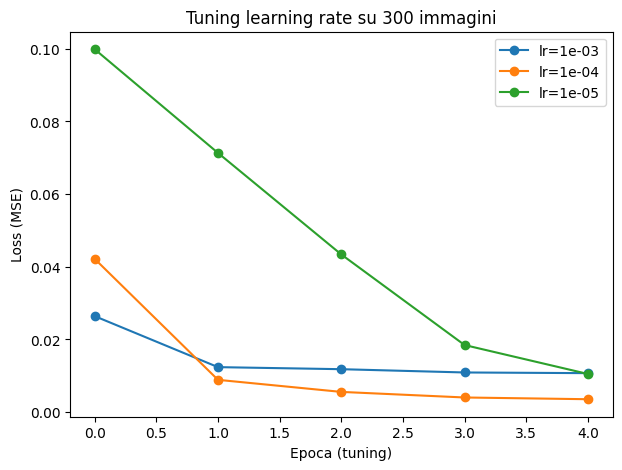

In [16]:
# hyperparameter tuning

from torch.utils.data import Subset
import random

TUNE_SUBSET_SIZE = 300
TUNE_EPOCHS = 5
LR_CANDIDATES = [1e-3, 1e-4, 1e-5]

subset_idx = random.sample(range(len(train_ds)), min(TUNE_SUBSET_SIZE, len(train_ds)))
tune_subset = Subset(train_ds, subset_idx)
tune_loader = DataLoader(tune_subset, batch_size=BATCH_SIZE, shuffle=True)

tune_results = {}

for lr in LR_CANDIDATES:
    model_tune = models.UNet(**MODEL_CONFIG).to(device)
    optimizer_tune = torch.optim.Adam(model_tune.parameters(), lr=lr)
    loss_fn_tune = nn.MSELoss()

    epoch_losses = []
    for epoch in range(TUNE_EPOCHS):
        running_loss = 0.0
        for x, y in tune_loader:
            x, y = x.to(device), y.to(device)
            optimizer_tune.zero_grad()
            y_pred = model_tune(x)
            loss = loss_fn_tune(y_pred, y)
            loss.backward()
            optimizer_tune.step()
            running_loss += loss.item()
        epoch_losses.append(running_loss / len(tune_loader))

    tune_results[lr] = epoch_losses
    print(f"lr={lr:.0e}  loss iniziale={epoch_losses[0]:.5f}  loss finale={epoch_losses[-1]:.5f}")

    del model_tune, optimizer_tune
    torch.cuda.empty_cache() if device.type == "cuda" else None

plt.figure(figsize=(7, 5))
for lr, losses_list in tune_results.items():
    plt.plot(losses_list, label=f"lr={lr:.0e}", marker="o")
plt.xlabel("Epoca (tuning)")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.title(f"Tuning learning rate su {TUNE_SUBSET_SIZE} immagini")
plt.show()

In [41]:
from tqdm.auto import tqdm

model = models.UNet(**MODEL_CONFIG).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = losses.MixedLoss(
    loss_vec=(nn.MSELoss(), losses.SSIMLoss()),
    weight_parameters=(1.0, 0.1),
)
scaler = torch.amp.GradScaler('cuda')

CHECKPOINT_PATH = CHECKPOINT_DIR / "model_weights.pth"   # unico file di pesi: solo il migliore
HISTORY_PATH = CHECKPOINT_DIR / "history.json"

start_epoch = 0
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_psnr": [], "val_ssim": []}

if HISTORY_PATH.exists():
    with open(HISTORY_PATH) as f:
        history = json.load(f)
    start_epoch = len(history["train_loss"])
    if history["val_loss"]:
        best_val_loss = min(history["val_loss"])
    if CHECKPOINT_PATH.exists():
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
        print(f"Checkpoint trovato, riprendo da epoca {start_epoch} (best val_loss finora: {best_val_loss:.5f}).")
else:
    print("Nessun checkpoint, parto da zero.")

for epoch in range(start_epoch, N_EPOCHS):
    model.train()
    running_loss = 0.0
    t0 = time.time()

    train_pbar = tqdm(train_loader, desc=f"Epoca {epoch+1}/{N_EPOCHS} [train]", leave=False)
    for x, y in train_pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        train_pbar.set_postfix(loss=f"{loss.item():.5f}")
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss, val_psnr, val_ssim = 0.0, 0.0, 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoca {epoch+1}/{N_EPOCHS} [val]", leave=False)
    with torch.no_grad():
        for x, y in val_pbar:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast('cuda'):
                y_pred = model(x)
                loss = loss_fn(y_pred, y)
            val_loss += loss.item()
            val_psnr += PSNR(y_pred.float().cpu(), y.float().cpu())
            val_ssim += SSIM(y_pred.float().cpu(), y.float().cpu())
    val_loss /= len(val_loader)
    val_psnr /= len(val_loader)
    val_ssim /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr if isinstance(val_psnr, float) else val_psnr.item())
    history["val_ssim"].append(val_ssim if isinstance(val_ssim, float) else val_ssim.item())

    elapsed = time.time() - t0
    is_best = val_loss < best_val_loss
    print(f"Epoca {epoch+1}/{N_EPOCHS} ({elapsed:.1f}s) -> "
          f"train_loss={train_loss:.5f}  val_loss={val_loss:.5f}  "
          f"val_PSNR={history['val_psnr'][-1]:.2f}  val_SSIM={history['val_ssim'][-1]:.4f}"
          f"{'  <-- nuovo migliore' if is_best else ''}")

    if is_best:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)   # salva SOLO se migliora

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)   # la history si salva sempre, ad ogni epoca

print(f"\nTraining completato. Miglior val_loss: {best_val_loss:.5f}")

Nessun checkpoint, parto da zero.


Epoca 1/25 [train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoca 1/25 [val]:   0%|          | 0/36 [00:00<?, ?it/s]

Epoca 1/25 (56.8s) -> train_loss=0.03577  val_loss=0.02231  val_PSNR=25.74  val_SSIM=0.8170  <-- nuovo migliore


Epoca 2/25 [train]:   0%|          | 0/171 [00:00<?, ?it/s]

...

Epoca 24/25 (56.7s) -> train_loss=0.00672  val_loss=0.01620  val_PSNR=28.21  val_SSIM=0.8668


Epoca 25/25 [train]:   0%|          | 0/171 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0f4ab08f40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
Exception ignored in:   File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0f4ab08f40>assert self._parent_pid == os.getpid(), 'can only test a child process'

Traceback (most recent call last):
AssertionError  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
: can only test a child process    
self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoca 25/25 [val]:   0%|          | 0/36 [00:00<?, ?it/s]

Epoca 25/25 (56.7s) -> train_loss=0.00650  val_loss=0.01633  val_PSNR=27.93  val_SSIM=0.8666

Training completato. Miglior val_loss: 0.01610


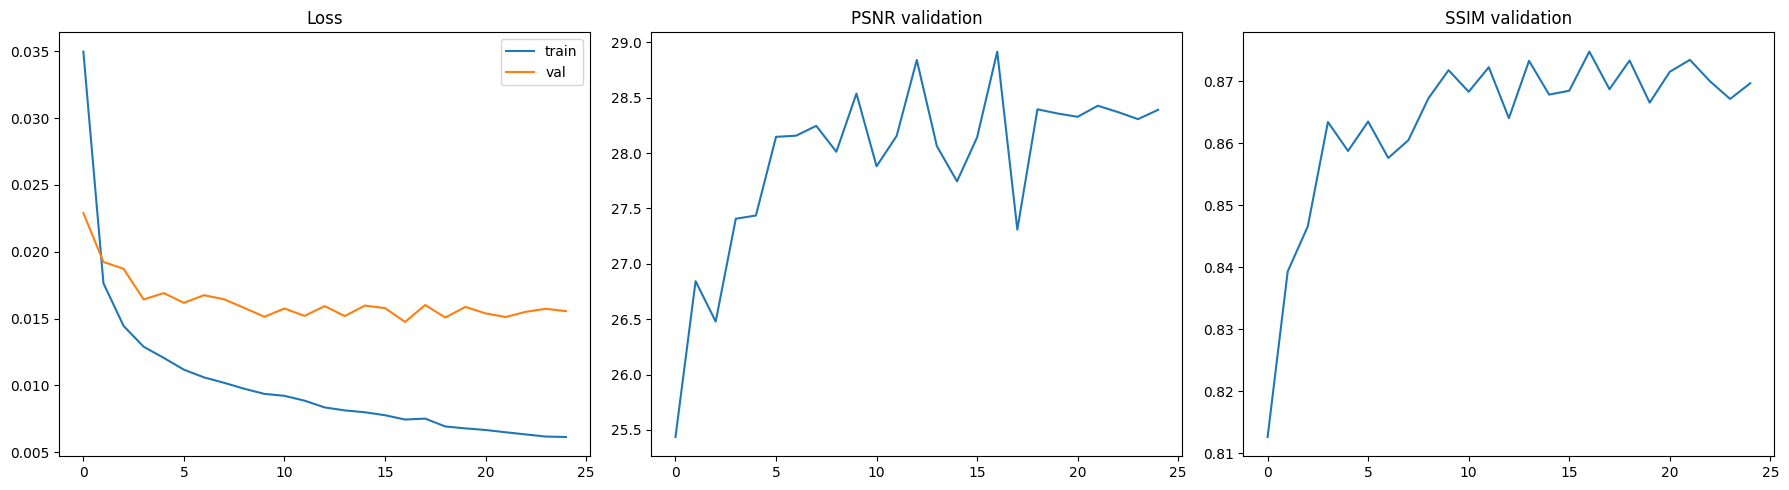

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_psnr"])
axes[1].set_title("PSNR validation")

axes[2].plot(history["val_ssim"])
axes[2].set_title("SSIM validation")

plt.tight_layout()
plt.show()